In [3]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/fmo_300k_64bd.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['electron occupations array']

df = pd.DataFrame(df)
df.to_excel('singleset_64bd.xlsx', index=False)

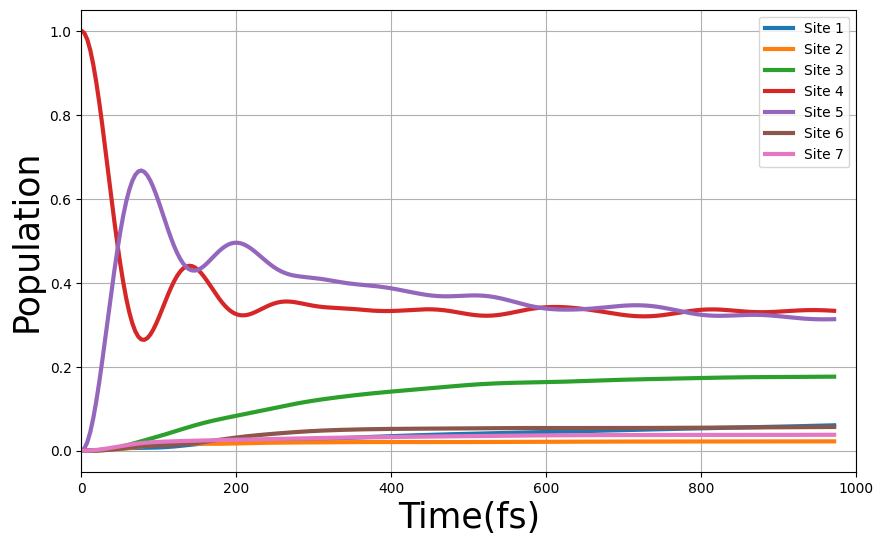

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取Excel文件
df = pd.read_excel('singleset_64bd.xlsx')
# df = pd.read_excel('/curie-home/zengjj/Renormalizer/test/fmo_benchmark.xlsx')

# 提取数据
x = np.arange(0,df.shape[0],1)
x = x * 160 * 0.024188843265

y_columns = df.iloc[:, 0:7]  # 第1-7列作为y坐标

# 创建图表
plt.figure(figsize=(10, 6))

# 绘制七条线
for i in range(0,7):
    plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

# 添加图表元素
plt.xlabel('Time(fs)',size = 25)
plt.ylabel('Population',size = 25)
plt.xlim((0, 1000))
plt.title('')
plt.legend()
plt.grid(True)

# 显示图表
plt.show()

Benchmark : singleset_256bd.xlsx
  行数=253, 列数=7, dt=3.8702 fs
  时间范围: 0 ~ 975.3 fs

  [已绘制] singleset  ($\chi'=64$)
    时间范围: 0 ~ 975.3 fs,  最大MAE=3.9855e-02,  均值MAE=1.9809e-02
  [已绘制] singleset  ($\chi'=128$)
    时间范围: 0 ~ 975.3 fs,  最大MAE=8.2908e-03,  均值MAE=3.9955e-03

✅ 已保存: FMO_MAE_vs_256bd.png


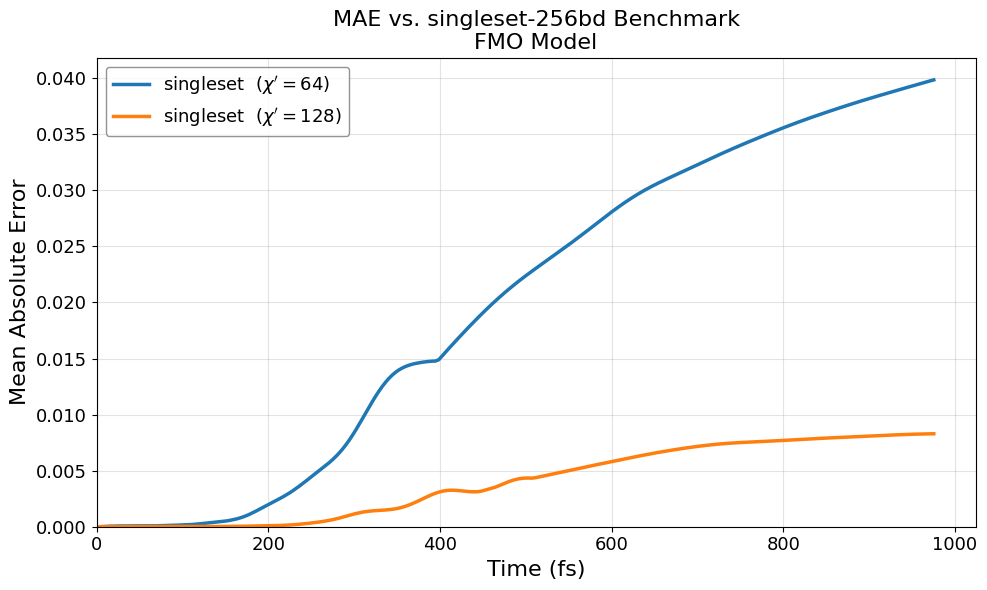

In [5]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fmo_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算其余三个文件的 Mean Absolute Error 并绘图。
    """

    # ============================================================
    # 1. 路径配置（只需修改此处）
    # ============================================================
    test_dir = "."   # ← 修改为你的文件夹路径，若在同目录则保持 "."

    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    # 需要对比的三个文件（按 bond dimension 从小到大排列）
    data_files = [
        # os.path.join(test_dir, "multiset_16bd.xlsx"),
        # os.path.join(test_dir, "multiset_64bd_old.xlsx"),
        os.path.join(test_dir, "singleset_64bd.xlsx"),
        os.path.join(test_dir, "singleset_128bd.xlsx"),
        # os.path.join(test_dir, "multiset_64bd.xlsx"),
    ]

    # ============================================================
    # 2. 样式配置：(标签, 颜色, 线型, 线宽)
    # ============================================================
    styles = {
        # "multiset_16bd.xlsx":  ("multiset  ($\\chi'=16$)",  "#4df01b", "--",  2.5),
        # "multiset_64bd_old.xlsx":  ("multiset_old  ($\\chi'=64$)",  "#f01b2d", "--",  2.5),
        "singleset_64bd.xlsx":  ("singleset  ($\\chi'=64$)",  "#1f77b4", "-",  2.5),
        "singleset_128bd.xlsx": ("singleset  ($\\chi'=128$)", "#ff7f0e", "-",  2.5),
        # "multiset_64bd.xlsx":   ("multiset   ($\\chi'=64$)",  "#2ca02c", "--", 2.5),
    }

    # ============================================================
    # 3. 时间步长（单位：fs）
    #    dt = 每步原子单位数 × 0.024188843265 fs/a.u.
    #    根据实际步长修改 dt_au
    # ============================================================
    dt_au = 160                          # ← 按需修改
    dt    = dt_au * 0.024188843265       # fs

    # ============================================================
    # 4. 读取 benchmark
    # ============================================================
    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]              # 自动识别列数（FMO 通常为 7 个 site）
    y_bm  = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm  = np.arange(len(y_bm)) * dt

    print(f"Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    # ============================================================
    # 5. 绘图
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        # 读取预测数据
        df_pred = pd.read_excel(fpath, header=None)
        y_pred  = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred  = np.arange(len(y_pred)) * dt

        # 将 benchmark 插值到预测时间轴上
        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算 Mean Absolute Error（对所有 site 取平均）
        mae = np.mean(np.abs(y_pred - y_bm_interp), axis=1)

        ax.plot(x_pred, mae,
                label=label,
                color=color,
                linestyle=ls,
                linewidth=lw)

        print(f"  [已绘制] {label}")
        print(f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
              f"最大MAE={mae.max():.4e},  均值MAE={mae.mean():.4e}")

    # ============================================================
    # 6. 坐标轴与标注
    # ============================================================
    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("Mean Absolute Error", fontsize=16)
    ax.set_title(
        "MAE vs. singleset-256bd Benchmark\n"
        "FMO Model",
        fontsize=16
    )
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("FMO_MAE_vs_256bd.png", dpi=150)
    print("\n✅ 已保存: FMO_MAE_vs_256bd.png")
    plt.show()


plot_fmo_error()